# Field rotation: model vs. measured, and their correlation

Combines the two sibling notebooks built earlier today:
- `fieldrotation.ipynb` -- the model's predicted rotator rate (`hexapod['rot_rate']`)
  vs. mount pointing (`mount_ha`, `mount_dec`).
- `fieldrotationcorrection.ipynb` -- the guider's *measured* residual rotation rate
  (a linear fit of `guider_centroids.rotation` vs. `obstime`) vs. the same pointing
  variables.

This notebook reruns both analyses against the **same exposure population** (one
shared `WHERE` filter, defined once in the Configuration cell below), each as its
own separate `select_exposures` call producing its own DataFrame (`df_model`,
`df_measured`) -- not one combined call -- so each half stays close to its source
notebook and easy to diff against it. Both original spatial plots are kept as-is
(one per DataFrame) so the two patterns can still be inspected individually, exactly
as before.

A new **Statistics** section at the end asks two questions the two heatmaps alone
can't answer:
1. Does a high/low model rate correlate with a large measured residual?
2. Does the measured residual actually depend on pointing, in a way you can put a
   number and a p-value on (not just eyeballing a heatmap)?

**Methodology note (discussed and confirmed 2026-07-20, before writing this
section)**: both questions are answered on the **raw, per-exposure, signed**
values -- never on values pre-averaged into the heatmap's spatial bins. Correlating
(or regressing on) bin-averaged values instead of raw points is a classic trap
(*ecological correlation* / the spatial-stats flavor of Simpson's paradox): a
relationship computed on aggregated group means can look different -- even flip
sign -- from the same relationship computed on the individual points. The measured
slope's **sign** matters (a systematic bias that flips across the meridian looks
very different from pure scatter), so `rotation_rate_slope` is used signed
throughout, never as an absolute value. Binning is used only for the two existing
spatial plots (unchanged) and the final Statistics-section plot -- never as an
input to the correlation/regression itself.

**Caveat worth keeping in mind**: exposures aren't fully independent samples (same
night/program cluster in time and observing conditions), so p-values from the
correlation/regression below are probably a bit optimistic. Fine for exploratory
work; don't over-trust a borderline p-value.

In [1]:
import os
import sys

# Add telemetry_mining to the path. Point DOS_TELEMETRY_MINING_DIR at your own
# checkout (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk);
# defaults to the maintainer's checkout at NERSC.
TM_DIR = os.getenv("DOS_TELEMETRY_MINING_DIR", os.path.expanduser("~/telemetry_mining-trunk/src"))
sys.path.insert(0, TM_DIR)

## Configuration -- edit this cell to repurpose the notebook

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d, spearmanr
import statsmodels.api as sm

from telemetry_mining import select_exposures

# ---- Exposure selection: set exactly one of NIGHT_RANGE / EXPIDS ----
# Shared by both select_exposures calls below -- both analyses run against the
# exact same exposure population.
NIGHT_RANGE = [20230101, 20260701]   # matches fieldrotation.ipynb / fieldrotationcorrection.ipynb's current setting
EXPIDS = None                        # e.g. an explicit exposure list

WHERE_EXTRA = "sequence = %s and totteff > %s and (program like %s or program like %s)"
WHERE_PARAMS = ('DESI', 60.0, 'DARK', 'BRIGHT')

# ---- Shared X/Y: mount pointing ----
X_SPEC, X_LABEL = "db_row.tcs['mount_ha']", "Mount hour angle (deg)"
Y_SPEC, Y_LABEL = "db_row.tcs['mount_dec']", "Mount declination (deg)"

# ---- C for the model half (fieldrotation.ipynb): free, from the bulk db_row query ----
MODEL_C_SPEC, MODEL_C_LABEL = "db_row.hexapod['rot_rate']", "Model rotator rate (arcsec/min)"
# ---- C for the measured half (fieldrotationcorrection.ipynb): a derived per-exposure
# quantity -- one extra telemetry.guider_centroids round-trip per exposure ----
MIN_GUIDE_FRAMES = 40  # exposures with fewer guider frames contribute None (dropped, not an error)
MAX_WORKERS = 8         # thread pool for the measured half's per-exposure guider fetch; None = sequential


def rotation_rate_slope(exp):
    """Fitted slope of guider-measured field rotation vs. time (see intro cell)."""
    frames = exp.guider_centroids
    if len(frames) < MIN_GUIDE_FRAMES:
        return None
    t_min = (frames["obstime"] - frames["obstime"].iloc[0]).dt.total_seconds() / 60.0
    slope, _intercept = np.polyfit(t_min, frames["rotation"], 1)
    return slope


MEASURED_C_LABEL = "Measured field-rotation rate (guider fit, arcsec/min)"

# ---- Plot (shared style for both spatial plots) ----
PLOT_MODE = "heatmap"   # "scatter" or "heatmap"
HEATMAP_BINS = 60
HEATMAP_STAT = "mean"   # mean preserves sign -- see the intro cell's methodology note

## Build the shared `WHERE` filter

Both `select_exposures` calls below reuse this exact `where`/`params` -- the model
and measured analyses run against the identical exposure population, so the final
Statistics section is comparing like with like. Any difference between
`df_model`'s and `df_measured`'s EXPID sets afterward comes only from independent
`on_error="skip"` drops or `MIN_GUIDE_FRAMES` rejections (the latter only applies
to the measured half), not from a different population.

In [23]:
assert (NIGHT_RANGE is None) != (EXPIDS is None), "set exactly one of NIGHT_RANGE or EXPIDS, not both/neither"

if NIGHT_RANGE is not None:
    where = f"night between %s and %s and ({WHERE_EXTRA})"
    params = (NIGHT_RANGE[0], NIGHT_RANGE[1]) + tuple(WHERE_PARAMS)
else:
    where = f"id = ANY(%s) and ({WHERE_EXTRA})"
    params = (list(EXPIDS),) + tuple(WHERE_PARAMS)

## Shared plotting helper

Identical to both source notebooks' plotting cell, factored into one function
since it's used twice below (once per DataFrame) with only the data/labels
differing -- same rendering logic and options (`PLOT_MODE`/`HEATMAP_STAT`) as
before, nothing new.

In [24]:
def plot_xyz(df, c_label, title_prefix):
    if PLOT_MODE == "scatter":
        plt.figure(figsize=(7, 6))
        sc = plt.scatter(df["X"], df["Y"], c=df["C"], cmap="viridis", s=15)
        plt.colorbar(sc, label=c_label)
    elif PLOT_MODE == "heatmap":
        stat, xedges, yedges, _ = binned_statistic_2d(
            df["X"], df["Y"], df["C"], statistic=HEATMAP_STAT, bins=HEATMAP_BINS
        )
        plt.figure(figsize=(7, 6))
        im = plt.imshow(
            stat.T, origin="lower", aspect="auto",
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis",
        )
        plt.colorbar(im, label=f"{HEATMAP_STAT}({c_label})")
    else:
        raise ValueError(f"PLOT_MODE must be 'scatter' or 'heatmap', got {PLOT_MODE!r}")

    plt.xlabel(X_LABEL)
    plt.ylabel(Y_LABEL)
    plt.title(f"{title_prefix}: {c_label}\nvs. {X_LABEL} / {Y_LABEL}  (n={len(df)})")
    plt.show()

## Model half (`fieldrotation.ipynb`): select + plot

`MODEL_C_SPEC` is a `db_row.*` path -- free, from the same bulk query already used
for the `WHERE` filter, so this call costs exactly one DB round-trip no matter how
many exposures match.

In [25]:
selection_model = select_exposures(
    where,
    columns={"X": X_SPEC, "Y": Y_SPEC, "C": MODEL_C_SPEC},
    params=params,
    on_error="skip",
)
skipped_model = selection_model.attrs["skipped"]
df_model = selection_model.dropna(subset=["X", "Y", "C"])

print(f'[model] {len(selection_model)} exposures matched, {len(skipped_model)} skipped on error, '
      f'{len(selection_model) - len(df_model)} more dropped for a missing X/Y/C value '
      f'-> {len(df_model)} exposures to plot')
df_model.head()

[model] 12043 exposures matched, 0 skipped on error, 0 more dropped for a missing X/Y/C value -> 12043 exposures to plot


,EXPID,NIGHT,X,Y,C
0,161983,20230104,27.201894,-6.77446,0.359
1,161989,20230104,-41.992317,70.69401,0.727
2,161990,20230104,-41.842651,67.81518,0.662
3,161991,20230104,-36.729777,62.94327,0.616
4,161992,20230104,-32.410485,20.39994,0.375


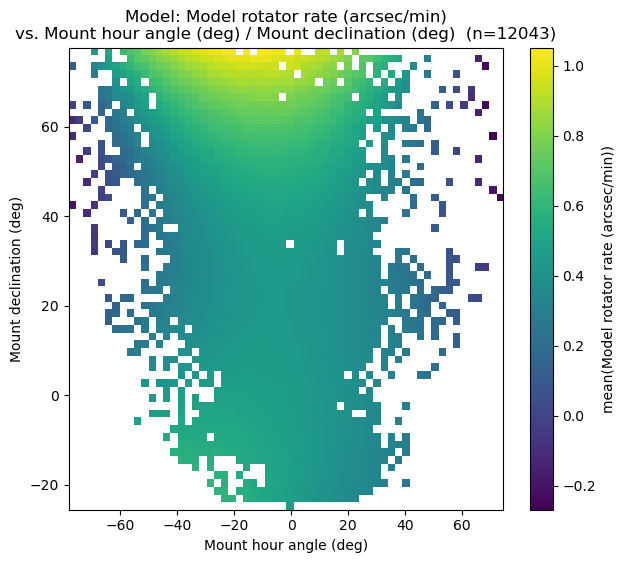

In [26]:
plot_xyz(df_model, MODEL_C_LABEL, "Model")

## Measured half (`fieldrotationcorrection.ipynb`): select + plot

`rotation_rate_slope` costs one extra `telemetry.guider_centroids` round-trip per
exposure (fit a line, return the slope). `max_workers=MAX_WORKERS` parallelizes
this over a thread pool -- see `API.md`'s `select_exposures` docs for why threads
(not processes) and the measured ~4x speedup this gave on a real 29-exposure
test.

In [27]:
selection_measured = select_exposures(
    where,
    columns={"X": X_SPEC, "Y": Y_SPEC, "C": rotation_rate_slope},
    params=params,
    on_error="skip",
    max_workers=MAX_WORKERS,
)
skipped_measured = selection_measured.attrs["skipped"]
df_measured = selection_measured.dropna(subset=["X", "Y", "C"])

print(f'[measured] {len(selection_measured)} exposures matched, {len(skipped_measured)} skipped on error, '
      f'{len(selection_measured) - len(df_measured)} more dropped for a missing X/Y/C value '
      f'(includes MIN_GUIDE_FRAMES={MIN_GUIDE_FRAMES} rejections) '
      f'-> {len(df_measured)} exposures to plot')
df_measured.head()

[measured] 9698 exposures matched, 2345 skipped on error, 378 more dropped for a missing X/Y/C value (includes MIN_GUIDE_FRAMES=40 rejections) -> 9320 exposures to plot


,EXPID,NIGHT,X,Y,C
2,163700,20230118,-12.443015,-0.61909,-0.051279
3,163820,20230119,8.720608,1.48857,0.112449
4,163821,20230119,15.573836,5.72247,-0.287183
5,163822,20230119,5.196391,-1.84834,-0.058436
6,163823,20230119,12.054471,1.24540,0.081628


## Statistics: does the measured residual correlate with the model rate, or with pointing?

`df_model` and `df_measured` came from two separate `select_exposures` calls
against the same `WHERE` filter, so they may not have identical EXPID sets
(independent `on_error="skip"` drops, plus `MIN_GUIDE_FRAMES` rejections that only
apply to the measured half). An inner join on `EXPID` keeps only exposures present
-- and successfully resolved -- in both.

All of the below uses the raw, signed, per-exposure values from that merged table,
never the heatmaps' binned means (see the intro cell's methodology note).

In [29]:
merged = df_model[["EXPID", "X", "Y", "C"]].rename(columns={"C": "rot_rate_model"}).merge(
    df_measured[["EXPID", "C"]].rename(columns={"C": "rot_rate_measured"}),
    on="EXPID",
)
print(f'{len(df_model)} model rows, {len(df_measured)} measured rows -> {len(merged)} exposures in both')

rho, p_value = spearmanr(merged["rot_rate_model"], merged["rot_rate_measured"])
print(f"Spearman rho(model rate, measured rate) = {rho:.3f}  (p = {p_value:.3g}, n = {len(merged)})")

12043 model rows, 9320 measured rows -> 9320 exposures in both
Spearman rho(model rate, measured rate) = -0.033  (p = 0.00127, n = 9320)


In [30]:
# Pointing dependence: rot_rate_measured ~ mount_ha + mount_dec, raw and signed.
# Add an interaction term (merged["X"] * merged["Y"]) if you suspect the effect
# isn't separable between HA and Dec (e.g. flexure that depends on both together).
design = sm.add_constant(merged[["X", "Y"]])
ols_model = sm.OLS(merged["rot_rate_measured"], design).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      rot_rate_measured   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     174.0
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           6.32e-75
Time:                        18:05:27   Log-Likelihood:                 5475.7
No. Observations:                9320   AIC:                        -1.095e+04
Df Residuals:                    9317   BIC:                        -1.092e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0156      0.002     -7.895      0.0

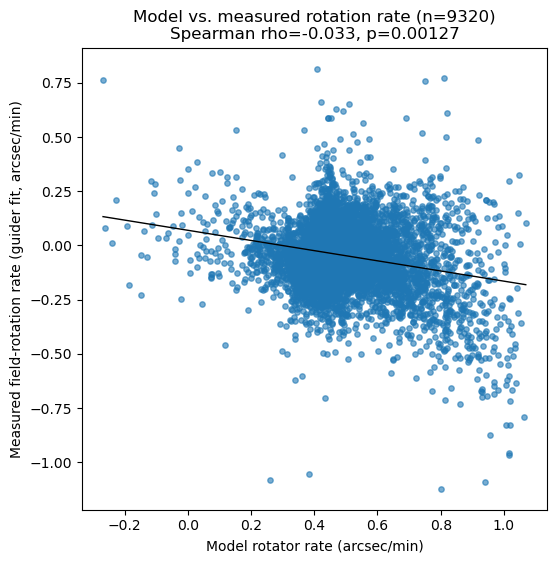

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(merged["rot_rate_model"], merged["rot_rate_measured"], s=15, alpha=0.6)

# A simple 1D fit line for visual guidance only -- the OLS above (pointing
# dependence) is the actual statistical test; this is a different, 1D relationship.
guide_slope, guide_intercept = np.polyfit(merged["rot_rate_model"], merged["rot_rate_measured"], 1)
xs = np.linspace(merged["rot_rate_model"].min(), merged["rot_rate_model"].max(), 100)
plt.plot(xs, guide_slope * xs + guide_intercept, color="black", linewidth=1)

plt.xlabel(MODEL_C_LABEL)
plt.ylabel(MEASURED_C_LABEL)
plt.title(f"Model vs. measured rotation rate (n={len(merged)})\nSpearman rho={rho:.3f}, p={p_value:.3g}")
plt.show()

In [38]:
# save csv version of merged DF
merged.to_csv("merged_rot.csv",index=False)

## Recap

This notebook combines `fieldrotation.ipynb` (model) and `fieldrotationcorrection.ipynb`
(measured) against one shared exposure population, keeps both original spatial
plots as-is, and adds a Statistics section that:
1. Computes Spearman rho (raw, signed, unbinned) between the model's `rot_rate`
   and the guider-measured residual slope.
2. Fits `rot_rate_measured ~ mount_ha + mount_dec` (raw, unbinned, signed) via
   OLS, to test pointing-dependence with an actual p-value rather than
   eyeballing a heatmap.
3. Plots the two rates against each other directly, with a Spearman rho/p-value
   annotation and a simple visual-guide fit line (not the OLS above -- that's a
   pointing-dependence regression, this is a different, 1D relationship).

### Result

**Smoke-tested only, not yet a real result.** The saved outputs above are from a
temporary 2-night smoke-test window (`NIGHT_RANGE = [20250201, 20250202]`, 57
exposures) used only to confirm the whole notebook runs end-to-end without
errors -- `NIGHT_RANGE` in the Configuration cell has since been restored to
`[20250701, 20260701]` (matching the sibling notebooks' current setting), so the
config and the displayed outputs/plots are currently **out of sync**: re-run the
notebook before reading anything into the numbers shown above.

For what it's worth, the smoke-test run itself was internally consistent and not
obviously wrong: `Spearman rho(model rate, measured rate) = -0.311` (p = 0.019,
n = 57), and the pointing regression found `mount_ha` significant (p = 0.007)
but `mount_dec` not (p = 0.618) -- at just 57 exposures from a 2-night window,
not something to draw a real conclusion from, but a sign the mechanics (merge,
Spearman, OLS) are doing something sensible.

_Fill in after running at your chosen `NIGHT_RANGE`/`WHERE_EXTRA`: the actual
Spearman rho/p, the OLS pointing-dependence coefficients/p-values, and what they
mean physically._